In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df=pd.read_csv("C:\ML_work\Datasets\Customer_Churn\customer_churn_data.csv")

<>:1: SyntaxWarning: invalid escape sequence '\M'
<>:1: SyntaxWarning: invalid escape sequence '\M'
C:\Users\roshn\AppData\Local\Temp\ipykernel_23792\2981177705.py:1: SyntaxWarning: invalid escape sequence '\M'
  df=pd.read_csv("C:\ML_work\Datasets\Customer_Churn\customer_churn_data.csv")


In [3]:
df.shape

(5880, 21)

In [ ]:
pd.set_option('display.max_columns', None)
df.head(2)
df.head(2)

AttributeError: 'DataFrame' object has no attribute 'set_options'

In [68]:
df.nunique()

customerID          5880
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                72
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      4439
TotalCharges        5794
Churn                  2
dtype: int64

In [69]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [59]:
def conv_binary(feature_name):
    if df[feature_name].nunique() >= 2 and df[feature_name].nunique() <= 5:
        print(f"Feature '{feature_name}' has values count is {df[feature_name].value_counts()}")
    return df
for i in df.columns:
    conv_binary(i)

Feature 'gender' has values count is gender
Male      2950
Female    2930
Name: count, dtype: int64
Feature 'SeniorCitizen' has values count is SeniorCitizen
1    2944
0    2936
Name: count, dtype: int64
Feature 'Partner' has values count is Partner
Yes    2995
No     2885
Name: count, dtype: int64
Feature 'Dependents' has values count is Dependents
No     3004
Yes    2876
Name: count, dtype: int64
Feature 'PhoneService' has values count is PhoneService
Yes    2941
No     2939
Name: count, dtype: int64
Feature 'MultipleLines' has values count is MultipleLines
No phone service    2939
Yes                 1512
No                  1429
Name: count, dtype: int64
Feature 'InternetService' has values count is InternetService
No             2029
DSL            1936
Fiber optic    1915
Name: count, dtype: int64
Feature 'OnlineSecurity' has values count is OnlineSecurity
No internet service    2029
No                     1947
Yes                    1904
Name: count, dtype: int64
Feature 'Online

In [60]:
def conv_binary(feature_name):
    if df[feature_name].nunique() ==2:
        df[feature_name] = df[feature_name].map(lambda x: 1 if x==df[feature_name].unique()[0] else 0)
    else:
        print(f"Feature '{feature_name}' is not binary and cannot be converted.")
    return df
for i in df.columns:
    conv_binary(i)

Feature 'customerID' is not binary and cannot be converted.
Feature 'tenure' is not binary and cannot be converted.
Feature 'MultipleLines' is not binary and cannot be converted.
Feature 'InternetService' is not binary and cannot be converted.
Feature 'OnlineSecurity' is not binary and cannot be converted.
Feature 'OnlineBackup' is not binary and cannot be converted.
Feature 'DeviceProtection' is not binary and cannot be converted.
Feature 'TechSupport' is not binary and cannot be converted.
Feature 'StreamingTV' is not binary and cannot be converted.
Feature 'StreamingMovies' is not binary and cannot be converted.
Feature 'Contract' is not binary and cannot be converted.
Feature 'PaymentMethod' is not binary and cannot be converted.
Feature 'MonthlyCharges' is not binary and cannot be converted.
Feature 'TotalCharges' is not binary and cannot be converted.


In [61]:
df.drop("customerID",axis=1,inplace=True)

In [62]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,1,1,1,23,1,No phone service,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,1,Bank transfer,49.85,1146.55,1
1,0,1,0,0,43,1,No phone service,DSL,Yes,No,Yes,No,Yes,No,Month-to-month,0,Mailed check,100.70,4330.10,0
2,1,0,1,0,51,0,No,DSL,No,Yes,Yes,Yes,No,No,One year,0,Electronic check,97.33,4963.83,0
3,1,0,1,0,72,0,Yes,DSL,Yes,No,Yes,No,No,No,Month-to-month,0,Credit card,101.38,7299.36,1
4,1,0,1,0,25,0,Yes,DSL,No,No,No,Yes,No,Yes,Month-to-month,0,Electronic check,52.22,1305.50,0


In [63]:
def conv_binary(feature_name):
    if df[feature_name].dtype == 'int64' or df[feature_name].dtype == 'float64':
        corr=df['Churn'].corr(df[feature_name])
        print(f"Feature '{feature_name}' has correlation with target variable is {corr}") 
    else:
        print(f"Feature '{feature_name}' has data type is {df[feature_name].dtype} and cannot be used for correlation.")
    return df
for i in df.columns:
    conv_binary(i)

Feature 'gender' has correlation with target variable is -0.008212741751608932
Feature 'SeniorCitizen' has correlation with target variable is -0.004742956805168731
Feature 'Partner' has correlation with target variable is 0.010134002742221865
Feature 'Dependents' has correlation with target variable is -0.0010499185922617147
Feature 'tenure' has correlation with target variable is -0.008599723357449133
Feature 'PhoneService' has correlation with target variable is -0.018024192137513783
Feature 'MultipleLines' has data type is str and cannot be used for correlation.
Feature 'InternetService' has data type is str and cannot be used for correlation.
Feature 'OnlineSecurity' has data type is str and cannot be used for correlation.
Feature 'OnlineBackup' has data type is str and cannot be used for correlation.
Feature 'DeviceProtection' has data type is str and cannot be used for correlation.
Feature 'TechSupport' has data type is str and cannot be used for correlation.
Feature 'StreamingT

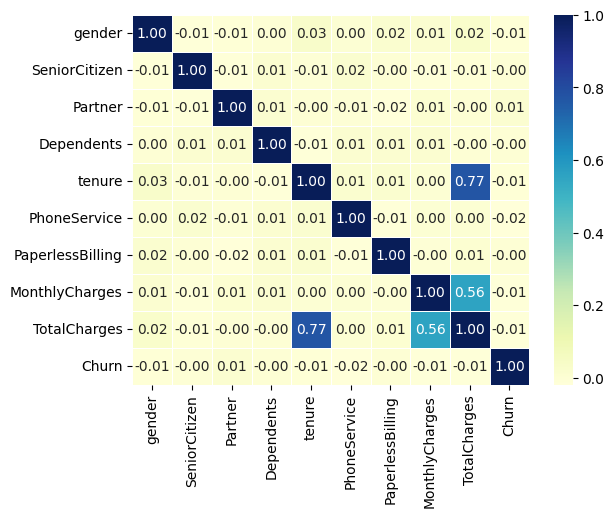

In [64]:
# Compute correlation matrix
co_mtx = df.corr(numeric_only=True)

# Plot correlation heatmap
sns.heatmap(co_mtx, cmap="YlGnBu", annot=True, fmt=".2f", linewidths=.5)

# Display heatmap
plt.show()